# 신용카드사기탐지_모델만들기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
data = pd.read_csv("./data/fraud.csv")


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

In [4]:
data.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011,-82.048,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159,-118.186,0


In [5]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1852394 non-null  object 
 1   cc_num                 1852394 non-null  int64  
 2   merchant               1852394 non-null  object 
 3   category               1852394 non-null  object 
 4   amt                    1852394 non-null  float64
 5   first                  1852394 non-null  object 
 6   last                   1852394 non-null  object 
 7   gender                 1852394 non-null  object 
 8   street                 1852394 non-null  object 
 9   city                   1852394 non-null  object 
 10  state                  1852394 non-null  object 
 11  zip                    1852394 non-null  int64  
 12  lat                    1852394 non-null  float64
 13  long                   1852394 non-null  float64
 14  city_pop          

In [6]:
data[['amt', 'city_pop']].describe()

,amt,city_pop
count,1852394.000,1852394.000
mean,70.064,88643.675
std,159.254,301487.618
min,1.000,23.000
25%,9.640,741.000
50%,47.450,2443.000
75%,83.100,20328.000
max,28948.900,2906700.000


In [7]:
data.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [8]:
obj_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(exclude='object')

In [17]:
obj_cols.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'first', 'last',
       'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num'],
      dtype='object')

In [20]:
for col in obj_cols:
    print("=" * 30, col, "=" * 30)
    print("nunique: ", obj_cols[col].nunique(), end="\n\n")
    print(obj_cols[col].value_counts(), end="\n\n")
    print(data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False), end="\n\n")

============================== trans_date_trans_time ==============================
nunique:  1819551

trans_date_trans_time
2019-04-22 16:02:01    4
2020-06-01 01:37:47    4
2020-06-02 12:47:07    4
2020-10-05 19:37:49    4
2020-12-13 17:53:47    4
                      ..
2019-01-01 00:20:15    1
2019-01-01 00:21:32    1
2019-01-01 00:22:06    1
2019-01-01 00:22:18    1
2019-01-01 00:00:44    1
Name: count, Length: 1819551, dtype: int64

                       is_fraud
trans_date_trans_time          
2019-09-11 22:58:11       1.000
2019-12-22 01:09:30       1.000
2019-02-12 23:49:17       1.000
2019-09-23 06:33:47       1.000
2019-05-03 04:38:52       1.000
...                         ...
2019-01-01 00:20:15       0.000
2019-01-01 00:21:32       0.000
2019-01-01 00:22:06       0.000
2019-01-01 00:22:18       0.000
2019-01-01 00:00:44       0.000

[1819551 rows x 1 columns]

============================== merchant ==============================
nunique:  693

merchant
fraud_Kilback LL

                                is_fraud
job                                     
Air traffic controller             1.000
Careers adviser                    1.000
Broadcast journalist               1.000
Armed forces technical officer     1.000
Contracting civil engineer         1.000
...                                  ...
Health physicist                   0.001
Contractor                         0.000
Engineer, communications           0.000
Engineer, drilling                 0.000
Stage manager                      0.000

[497 rows x 1 columns]

============================== dob ==============================
nunique:  984

dob
1977-03-23    8044
1988-09-15    6574
1981-08-29    6571
1955-05-06    5121
1960-01-13    4395
              ... 
1936-05-04       7
1964-09-17       7
1963-02-26       7
1999-10-26       7
1998-08-02       6
Name: count, Length: 984, dtype: int64

            is_fraud
dob                 
1927-02-03     1.000
1932-08-10     1.000
1932-05-09     1.000
193

In [21]:
data[data['state'] =='DE']

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
233631,2019-04-28 00:41:37,6011826317034777,fraud_Schamberger-O'Keefe,grocery_pos,294.910,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,8f85e701f609911b99bea627eb71aa49,1335573697,38.167,-75.023,1
233744,2019-04-28 01:49:28,6011826317034777,fraud_Kuphal-Predovic,misc_net,868.290,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,8c941f2849ccac44d32ef08ea784fc67,1335577768,38.911,-74.857,1
233826,2019-04-28 02:33:09,6011826317034777,fraud_Goodwin-Nitzsche,grocery_pos,280.260,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,0fc1109cb9a10961595e79736ccc1293,1335580389,38.523,-74.461,1
234625,2019-04-28 10:24:34,6011826317034777,"fraud_Huel, Hammes and Witting",grocery_pos,296.250,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,b4248cfc8b44fec6193767918d49b334,1335608674,38.594,-76.031,1
236522,2019-04-28 23:03:24,6011826317034777,fraud_Waters-Cruickshank,health_fitness,20.580,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,567ed9b2d7d10ad519cdd697cd338f70,1335654204,39.004,-75.852,1
236643,2019-04-28 23:41:43,6011826317034777,fraud_Cormier LLC,shopping_net,1012.770,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,00d158609d7ac753da792e9d0eb88a0b,1335656503,39.596,-75.559,1
237095,2019-04-29 03:29:41,6011826317034777,fraud_Ruecker Group,misc_net,885.960,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,e0613e4142b2d05867299832ac453e01,1335670181,39.666,-76.359,1
237740,2019-04-29 10:13:47,6011826317034777,fraud_Smitham-Schiller,grocery_net,10.930,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,788a8fea8199a4e8a6a47ffab824e571,1335694427,37.692,-76.058,1
239854,2019-04-29 23:51:22,6011826317034777,"fraud_Baumbach, Feeney and Morar",shopping_net,960.490,Christine,Johnson,F,9612 Robert Light Apt. 340,Georgetown,DE,19947,38.679,-75.393,18799,"Designer, multimedia",2000-03-16,4193b953223a1c9432f9d3c380e67be9,1335743482,39.073,-75.545,1


'trans_date_trans_time', 'merchant', 'category', 'gender', 'job'

In [22]:
from ydata_profiling import ProfileReport

C:\Users\haram\miniforge3\envs\fintech\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
profile = ProfileReport(data, title="Profiling Report")

In [24]:
profile.to_file("is_froad_eda.html")

Export report to file: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 17.24it/s]


* 집위치와 상점 위치가 서로 연관이 있다.
* cc_num 의 유일값이 999개다.

In [25]:
data['cc_num'].nunique()

999

is_froad의 비율

In [28]:
data['is_fraud'].mean() * 100

np.float64(0.5210014716091717)

# 카드별(고객) 거래 금액에서의 이상치 찾고 is_fraud와의 관계 보기

In [9]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [10]:
amt_desc = data.groupby(['cc_num'])['amt'].describe()
amt_desc

,count,mean,std,min,25%,50%,75%,max
cc_num,,,,,,,,
60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460
60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370
60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770
60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360
60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460
...,...,...,...,...,...,...,...,...
4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860
4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440
4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430


In [11]:
amt_desc.columns

Index(['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'], dtype='object')

In [12]:
amt_desc['iqr_max'] = amt_desc['75%'] + (1.5 * (amt_desc['75%'] - amt_desc['25%']))
amt_desc

,count,mean,std,min,25%,50%,75%,max,iqr_max
cc_num,,,,,,,,,
60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460,170.666
60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370,204.100
60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770,175.486
60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360,159.065
60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460,164.995
...,...,...,...,...,...,...,...,...,...
4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860,197.892
4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440,206.697
4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430,195.946


In [13]:
amt_desc = amt_desc.reset_index()
amt_desc

,cc_num,count,mean,std,min,25%,50%,75%,max,iqr_max
0,60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460,170.666
1,60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370,204.100
2,60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770,175.486
3,60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360,159.065
4,60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460,164.995
...,...,...,...,...,...,...,...,...,...,...
994,4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860,197.892
995,4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440,206.697
996,4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430,195.946
997,4989847570577635369,1471.000,93.009,128.397,1.030,19.940,57.170,111.945,1223.850,249.952


# 원본 data와 그룹연산결과 합치기

In [14]:
amt_desc.columns

Index(['cc_num', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
       'iqr_max'],
      dtype='object')

In [15]:
amt_desc.columns = ['cc_num', 'count', 'amt_mean', 'amt_std', 'min', '25%', '50%', '75%', 'max',
       'amt_iqr_max']

In [16]:
amt_desc

,cc_num,count,amt_mean,amt_std,min,25%,50%,75%,max,amt_iqr_max
0,60416207185,2196.000,59.258,142.870,1.020,7.560,36.540,72.802,3437.460,170.666
1,60422928733,2200.000,65.483,92.043,1.010,9.075,51.405,87.085,1290.370,204.100
2,60423098130,738.000,96.376,1000.694,1.010,8.780,35.425,75.463,27119.770,175.486
3,60427851591,743.000,107.488,131.015,8.860,59.140,76.670,99.110,1164.360,159.065
4,60487002085,735.000,64.097,153.208,1.020,8.095,35.670,70.855,2758.460,164.995
...,...,...,...,...,...,...,...,...,...,...
994,4958589671582726883,2191.000,67.206,137.504,1.000,8.830,50.130,84.455,4292.860,197.892
995,4973530368125489546,1467.000,75.789,258.847,1.010,9.435,52.660,88.340,8749.440,206.697
996,4980323467523543940,736.000,70.709,119.903,1.010,8.465,42.515,83.458,1327.430,195.946
997,4989847570577635369,1471.000,93.009,128.397,1.030,19.940,57.170,111.945,1223.850,249.952


In [17]:
data = pd.merge(data, amt_desc[['cc_num','amt_mean', 'amt_std', 'amt_iqr_max']], how='left', on='cc_num')
data

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011,-82.048,0,89.409,127.530,256.620
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.888,-118.210,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159,-118.186,0,56.078,159.202,158.060
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.181,-112.262,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.151,-112.154,0,69.924,116.689,210.800
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.231,-112.114,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034,-112.561,0,80.090,280.078,193.098
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.675,-78.632,0,95.341,94.323,149.974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.493,-91.891,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.947,-91.333,0,62.348,110.821,182.535
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.039,-95.440,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661,-96.187,0,50.452,168.361,136.045
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.197,-118.902,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658,-119.715,0,88.704,119.949,261.548
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.626,-116.449,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.471,-117.081,0,60.998,89.526,186.940


In [18]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max'],
      dtype='object')

In [19]:
data = data.drop(['first', 'last', 'street', 'city', 'state', 'zip', 'trans_num', 'unix_time'], axis=1)
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940


In [20]:
data.loc[data['amt'] > data['amt_iqr_max'], 'is_fraud'].mean() * 100

np.float64(8.316776198481838)

# 사용금액의 zscore를 구한 후 사기 비율 계산
* zscore: (값-평균) / 표준편차  =  ? < -3  ,  > 3


In [21]:
data['amt_zscore'] = (data['amt'] - data['amt_mean']) / data['amt_std']

In [22]:
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620,-0.662
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060,0.321
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800,1.287
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098,-0.125
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974,-0.566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535,-0.168
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045,0.365
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548,-0.015
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940,-0.592


In [23]:
data[(data['amt_zscore'] < -3) | (data['amt_zscore'] > 3)]['is_fraud'].value_counts()

is_fraud
0    21725
1     4092
Name: count, dtype: int64

In [24]:
4092 / (4092+21725) * 100

15.850021303792076

In [25]:
data[(data['amt_zscore'] < -3) | (data['amt_zscore'] > 3)]['is_fraud'].mean() * 100

np.float64(15.850021303792076)

# 사용자가 어디에 주로 지출하는가?
* 식품에 지출이 많은 사람, 레저용품에 지출을 갑자기 많이 한다??
* 평소 지출하는 카테고리 혹은 가게가 아닌 경우
* 카드 번호별, 카테고리별 지출 평균, 표준편차

In [26]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore'],
      dtype='object')

In [27]:
cat_amt = data.groupby(['cc_num', 'category'])['amt'].agg(['mean', 'std']).reset_index()
cat_amt

,cc_num,category,mean,std
0,60416207185,entertainment,51.839,65.486
1,60416207185,food_dining,26.737,46.383
2,60416207185,gas_transport,59.779,15.758
3,60416207185,grocery_net,52.153,17.695
4,60416207185,grocery_pos,101.558,21.894
...,...,...,...,...
13166,4992346398065154184,misc_pos,60.003,167.226
13167,4992346398065154184,personal_care,48.777,49.524
13168,4992346398065154184,shopping_net,86.280,217.047
13169,4992346398065154184,shopping_pos,64.213,169.239


In [30]:
cat_amt.columns = ['cc_num', 'category', 'cat_amt_mean', 'cat_amt_std']
cat_amt

,cc_num,category,cat_amt_mean,cat_amt_std
0,60416207185,entertainment,51.839,65.486
1,60416207185,food_dining,26.737,46.383
2,60416207185,gas_transport,59.779,15.758
3,60416207185,grocery_net,52.153,17.695
4,60416207185,grocery_pos,101.558,21.894
...,...,...,...,...
13166,4992346398065154184,misc_pos,60.003,167.226
13167,4992346398065154184,personal_care,48.777,49.524
13168,4992346398065154184,shopping_net,86.280,217.047
13169,4992346398065154184,shopping_pos,64.213,169.239


In [31]:
cat_amt.head(100)

,cc_num,category,cat_amt_mean,cat_amt_std
0,60416207185,entertainment,51.839,65.486
1,60416207185,food_dining,26.737,46.383
2,60416207185,gas_transport,59.779,15.758
3,60416207185,grocery_net,52.153,17.695
4,60416207185,grocery_pos,101.558,21.894
5,60416207185,health_fitness,47.568,49.562
6,60416207185,home,55.925,53.243
7,60416207185,kids_pets,56.438,65.433
8,60416207185,misc_net,45.596,113.527
9,60416207185,misc_pos,59.537,164.192


In [32]:
data = pd.merge(data, cat_amt, how='left', on=['cc_num', 'category'])
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,mean,std,cat_amt_mean,cat_amt_std
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620,-0.662,84.861,116.070,84.861,116.070
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060,0.321,99.637,23.904,99.637,23.904
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800,1.287,46.653,60.385,46.653,60.385
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098,-0.125,61.537,15.747,61.537,15.747
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974,-0.566,35.481,4.935,35.481,4.935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535,-0.168,45.931,45.150,45.931,45.150
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045,0.365,50.924,52.342,50.924,52.342
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548,-0.015,63.857,52.309,63.857,52.309
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940,-0.592,8.192,27.244,8.192,27.244


In [35]:
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620,-0.662,84.861,116.070
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060,0.321,99.637,23.904
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800,1.287,46.653,60.385
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098,-0.125,61.537,15.747
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974,-0.566,35.481,4.935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535,-0.168,45.931,45.150
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045,0.365,50.924,52.342
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548,-0.015,63.857,52.309
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940,-0.592,8.192,27.244


In [36]:
data['cat_amt_zscore'] = (data['amt'] - data['cat_amt_mean']) / data['cat_amt_std']

In [37]:
data[(data['cat_amt_zscore'] < -3) | (data['cat_amt_zscore'] > 3)]['is_fraud'].mean() * 100

np.float64(19.290895447723862)

# 집의 위치와 가게의 위치 상관관계 높음
* 집과 가게의 거리를 위도 경도 데이터를 이용해 계산해서 평균 거리를 초과하는 곳에서 일어난 거래를 통해 부당 거래 검출

In [38]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore'],
      dtype='object')

# geopy 를 이용해 위도 경도 정보로 집과 가게의 거리 계산하기

In [39]:
from geopy.distance import distance

In [40]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore'],
      dtype='object')

In [ ]:
data['is_fraud'].apply()

In [41]:
data.loc[:3,:].apply(lambda x: print(x))

0    2019-01-01 00:00:18
1    2019-01-01 00:00:44
2    2019-01-01 00:00:51
3    2019-01-01 00:01:16
Name: trans_date_trans_time, dtype: object
0    2703186189652095
1        630423337322
2      38859492057661
3    3534093764340240
Name: cc_num, dtype: int64
0            fraud_Rippin, Kub and Mann
1       fraud_Heller, Gutmann and Zieme
2                  fraud_Lind-Buckridge
3    fraud_Kutch, Hermiston and Farrell
Name: merchant, dtype: object
0         misc_net
1      grocery_pos
2    entertainment
3    gas_transport
Name: category, dtype: object
0     4.970
1   107.230
2   220.110
3    45.000
Name: amt, dtype: float64
0    F
1    F
2    M
3    M
Name: gender, dtype: object
0   36.079
1   48.888
2   42.181
3   46.231
Name: lat, dtype: float64
0    -81.178
1   -118.210
2   -112.262
3   -112.114
Name: long, dtype: float64
0    3495
1     149
2    4154
3    1939
Name: city_pop, dtype: int64
0            Psychologist, counselling
1    Special educational needs teacher
2          Nature co

trans_date_trans_time    None
cc_num                   None
merchant                 None
category                 None
amt                      None
gender                   None
lat                      None
long                     None
city_pop                 None
job                      None
dob                      None
merch_lat                None
merch_long               None
is_fraud                 None
amt_mean                 None
amt_std                  None
amt_iqr_max              None
amt_zscore               None
cat_amt_mean             None
cat_amt_std              None
cat_amt_zscore           None
dtype: object

In [42]:
%%time
data['home_merch_dist'] = data.apply(lambda x: distance((x['lat'], x['long']), (x['merch_lat'], x['merch_long'])).km, axis=1)
data

CPU times: total: 10min 46s
Wall time: 11min 16s


,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620,-0.662,84.861,116.070,-0.688,78.774
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060,0.321,99.637,23.904,0.318,30.217
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800,1.287,46.653,60.385,2.873,108.103
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098,-0.125,61.537,15.747,-1.050,95.685
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974,-0.566,35.481,4.935,1.313,77.702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535,-0.168,45.931,45.150,-0.048,77.032
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045,0.365,50.924,52.342,1.164,100.024
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548,-0.015,63.857,52.309,0.440,80.888
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940,-0.592,8.192,27.244,-0.007,53.061


In [43]:
print(distance((data['lat'][0], data['long'][0]), (data['merch_lat'][0], data['merch_long'][0])).km)

78.77382075373654


In [44]:
dist_desc = data.groupby(['cc_num'])['home_merch_dist'].agg(['mean', 'std']).reset_index()
dist_desc

,cc_num,mean,std
0,60416207185,73.535,28.698
1,60422928733,78.986,29.299
2,60423098130,77.827,28.188
3,60427851591,75.712,28.977
4,60487002085,79.443,28.767
...,...,...,...
994,4958589671582726883,76.736,29.124
995,4973530368125489546,78.754,29.451
996,4980323467523543940,72.272,28.280
997,4989847570577635369,76.970,29.387


In [45]:
dist_desc.columns = ['cc_num', 'dist_mean', 'dist_std']
dist_desc

,cc_num,dist_mean,dist_std
0,60416207185,73.535,28.698
1,60422928733,78.986,29.299
2,60423098130,77.827,28.188
3,60427851591,75.712,28.977
4,60487002085,79.443,28.767
...,...,...,...
994,4958589671582726883,76.736,29.124
995,4973530368125489546,78.754,29.451
996,4980323467523543940,72.272,28.280
997,4989847570577635369,76.970,29.387


In [46]:
data = pd.merge(data, dist_desc, how='left', on='cc_num')
data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist,dist_mean,dist_std
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970,F,36.079,-81.178,3495,"Psychologist, counselling",1988-03-09,36.011,-82.048,0,89.409,127.530,256.620,-0.662,84.861,116.070,-0.688,78.774,77.842,30.072
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230,F,48.888,-118.210,149,Special educational needs teacher,1978-06-21,49.159,-118.186,0,56.078,159.202,158.060,0.321,99.637,23.904,0.318,30.217,71.657,28.091
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110,M,42.181,-112.262,4154,Nature conservation officer,1962-01-19,43.151,-112.154,0,69.924,116.689,210.800,1.287,46.653,60.385,2.873,108.103,74.581,28.884
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000,M,46.231,-112.114,1939,Patent attorney,1967-01-12,47.034,-112.561,0,80.090,280.078,193.098,-0.125,61.537,15.747,-1.050,95.685,72.049,28.892
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960,M,38.421,-79.463,99,Dance movement psychotherapist,1986-03-28,38.675,-78.632,0,95.341,94.323,149.974,-0.566,35.481,4.935,1.313,77.702,75.836,29.153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.770,M,40.493,-91.891,519,Town planner,1966-02-13,39.947,-91.333,0,62.348,110.821,182.535,-0.168,45.931,45.150,-0.048,77.032,75.524,28.959
1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.840,M,29.039,-95.440,28739,Futures trader,1999-12-27,29.661,-96.187,0,50.452,168.361,136.045,0.365,50.924,52.342,1.164,100.024,79.173,30.051
1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.880,F,46.197,-118.902,3684,Musician,1981-11-29,46.658,-119.715,0,88.704,119.949,261.548,-0.015,63.857,52.309,0.440,80.888,72.656,28.552
1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.990,M,44.626,-116.449,129,Cartographer,1965-12-15,44.471,-117.081,0,60.998,89.526,186.940,-0.592,8.192,27.244,-0.007,53.061,73.689,28.255


In [47]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore',
       'home_merch_dist', 'dist_mean', 'dist_std'],
      dtype='object')

In [48]:
data['dist_zscore'] = (data['home_merch_dist'] - data['dist_mean']) / data['dist_std']

In [49]:
data[(data['dist_zscore'] < -3) | (data['dist_zscore'] > 3)]

,trans_date_trans_time,cc_num,merchant,category,amt,gender,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,amt_mean,amt_std,amt_iqr_max,amt_zscore,cat_amt_mean,cat_amt_std,cat_amt_zscore,home_merch_dist,dist_mean,dist_std,dist_zscore


In [50]:
data.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'amt_mean', 'amt_std', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_mean', 'cat_amt_std', 'cat_amt_zscore',
       'home_merch_dist', 'dist_mean', 'dist_std', 'dist_zscore'],
      dtype='object')

In [51]:
data = data.drop(['cc_num', 'merchant', 'amt_mean', 'amt_std', 'cat_amt_mean', 'cat_amt_std',
          'dist_mean', 'dist_std', 'lat', 'long',
           'merch_lat', 'merch_long'], axis=1)

In [52]:
data.columns

Index(['trans_date_trans_time', 'category', 'amt', 'gender', 'city_pop', 'job',
       'dob', 'is_fraud', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore'],
      dtype='object')

# 나이 추출

In [80]:
data['trans_date_trans_time'][-1:][1852393][:4]

'2020'

In [69]:
data['age'] = data['dob'].apply(lambda x: 2020 - int(x[:4]))

In [70]:
data.head(2)

,trans_date_trans_time,category,amt,gender,city_pop,job,dob,is_fraud,amt_iqr_max,amt_zscore,cat_amt_zscore,home_merch_dist,dist_zscore,age
0,2019-01-01 00:00:18,misc_net,4.970,F,3495,"Psychologist, counselling",1988-03-09,0,256.620,-0.662,-0.688,78.774,0.031,32
1,2019-01-01 00:00:44,grocery_pos,107.230,F,149,Special educational needs teacher,1978-06-21,0,158.060,0.321,0.318,30.217,-1.475,42


<Axes: ylabel='Frequency'>

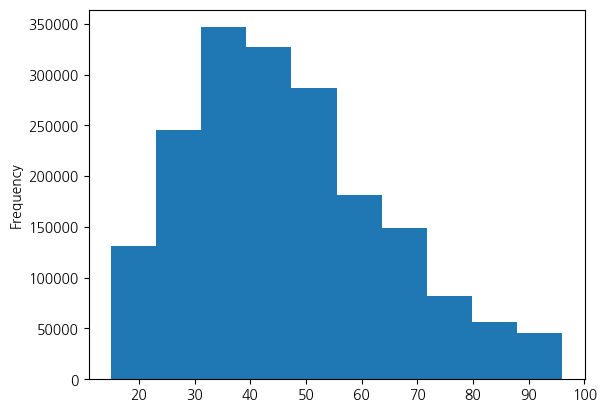

In [71]:
data['age'].plot(kind='hist')

In [74]:
data.groupby('age')['is_fraud'].mean().sort_values(ascending=False)

age
18   1.000
95   1.000
88   0.016
77   0.012
80   0.012
24   0.011
86   0.010
63   0.010
96   0.010
57   0.009
83   0.009
59   0.009
52   0.009
79   0.009
93   0.008
56   0.008
84   0.008
82   0.007
19   0.007
81   0.007
78   0.007
71   0.007
92   0.007
62   0.007
60   0.007
68   0.007
87   0.007
73   0.007
74   0.007
64   0.006
53   0.006
58   0.006
61   0.006
85   0.006
34   0.006
89   0.006
54   0.006
72   0.006
75   0.006
91   0.006
51   0.006
50   0.006
20   0.006
67   0.006
70   0.006
22   0.006
55   0.005
38   0.005
25   0.005
29   0.005
23   0.005
21   0.005
27   0.005
26   0.005
30   0.005
66   0.005
44   0.005
76   0.005
90   0.004
39   0.004
43   0.004
33   0.004
69   0.004
65   0.004
46   0.004
28   0.004
37   0.004
31   0.004
49   0.004
48   0.004
94   0.004
41   0.004
47   0.004
17   0.004
32   0.004
42   0.003
40   0.003
35   0.003
36   0.003
45   0.003
16   0.003
15   0.002
Name: is_fraud, dtype: float64

In [75]:
data['age'].value_counts()

age
48    65036
36    56964
33    53377
35    53335
46    48984
44    46820
34    45422
30    44601
47    44536
32    43853
42    43829
23    43178
45    43112
27    41732
49    39490
40    38716
50    36614
37    35834
43    35828
31    35816
29    35108
54    33692
58    32961
53    32230
51    29293
25    29289
38    29284
39    28531
26    28527
65    27804
21    27057
55    26364
41    25592
60    24934
59    24256
52    24241
64    24170
56    22740
66    22679
61    21976
28    21930
57    19109
62    19061
22    19040
75    17569
63    16884
68    15386
70    15385
67    15373
71    13925
20    13918
72    13913
69    13896
74    13188
78    11727
16    10967
81    10259
79     9531
85     9526
80     8844
24     8824
84     8798
91     8795
94     8783
19     8082
93     6601
89     6589
76     6580
92     5852
17     5833
77     5164
86     5152
83     5143
90     5114
82     4404
73     4400
87     4399
88     2965
15     2922
96      735
18       12
95       11
Name: count,

In [81]:
data.columns

Index(['trans_date_trans_time', 'category', 'amt', 'gender', 'city_pop', 'job',
       'dob', 'is_fraud', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'age'],
      dtype='object')

'trans_date_trans_time', 'dob' 삭제

In [83]:
data = data.drop(['trans_date_trans_time', 'dob' ], axis=1)

# 종속변수, 독립변수 분리, 훈련, 테스트 데이터로 나누기

In [84]:
X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

In [86]:
X.columns

Index(['category', 'amt', 'gender', 'city_pop', 'job', 'amt_iqr_max',
       'amt_zscore', 'cat_amt_zscore', 'home_merch_dist', 'dist_zscore',
       'age'],
      dtype='object')

In [99]:
X = pd.get_dummies(X, drop_first=True)

In [100]:
y.value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

In [89]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

* 홀드아웃, train, valid, test

In [101]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [102]:
print(len(X_train), len(X_valid), len(X_test))

1111436 370479 370479


In [103]:
print(y_train.value_counts())

is_fraud
0    1105645
1       5791
Name: count, dtype: int64


In [95]:
5791 / (5791+1105645)

0.005210376485915518

In [93]:
print(y_valid.value_counts())

is_fraud
0    368549
1      1930
Name: count, dtype: int64


In [96]:
1930 / (1930+368549)

0.005209472061844261

In [94]:
print(y_test.value_counts())

is_fraud
0    368549
1      1930
Name: count, dtype: int64


In [105]:
X_train.columns

Index(['amt', 'city_pop', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'age', 'category_food_dining',
       'category_gas_transport',
       ...
       'job_Visual merchandiser', 'job_Volunteer coordinator',
       'job_Warden/ranger', 'job_Warehouse manager',
       'job_Waste management officer', 'job_Water engineer',
       'job_Water quality scientist', 'job_Web designer',
       'job_Wellsite geologist', 'job_Writer'],
      dtype='object', length=518)

의사결정 나무로 분석하기

In [108]:
dtc = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_valid)
print(classification_report(y_valid, pred))
print("=" * 30, "test_result", "=" * 30)
test_pred = dtc.predict(X_test)
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.61      0.67      0.64      1930

    accuracy                           1.00    370479
   macro avg       0.81      0.83      0.82    370479
weighted avg       1.00      1.00      1.00    370479

============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.63      0.69      0.66      1930

    accuracy                           1.00    370479
   macro avg       0.81      0.84      0.83    370479
weighted avg       1.00      1.00      1.00    370479



In [109]:
print(dtc.get_params())

{'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [111]:
importance = pd.DataFrame(dtc.feature_importances_, columns=['importance'])
colum_name = pd.DataFrame(dtc.feature_names_in_, columns=['column'])

In [112]:
dtc_im_col = pd.concat([colum_name, importance], axis=1)
dtc_im_col

,column,importance
0,amt,0.661
1,city_pop,0.016
2,amt_iqr_max,0.012
3,amt_zscore,0.008
4,cat_amt_zscore,0.162
...,...,...
513,job_Water engineer,0.000
514,job_Water quality scientist,0.000
515,job_Web designer,0.000
516,job_Wellsite geologist,0.000


In [114]:
dtc_im_col.sort_values(by='importance', ascending=False).head(20)

,column,importance
0,amt,0.661
4,cat_amt_zscore,0.162
7,age,0.020
1,city_pop,0.016
10,category_grocery_net,0.014
2,amt_iqr_max,0.012
11,category_grocery_pos,0.012
20,category_travel,0.012
8,category_food_dining,0.011
13,category_home,0.011


In [107]:
for i in range(1, 11):
    dtc = DecisionTreeClassifier(max_depth=i, class_weight='balanced', random_state=42)
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_valid)
    print(classification_report(y_valid, pred))
    print("=" * 30, f"test_result {i}", "=" * 30)
    test_pred = dtc.predict(X_test)
    print(classification_report(y_test, test_pred))
    print()

              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.12      0.75      0.21      1930

    accuracy                           0.97    370479
   macro avg       0.56      0.86      0.60    370479
weighted avg       0.99      0.97      0.98    370479

============================== test_result 1 ==============================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.13      0.77      0.22      1930

    accuracy                           0.97    370479
   macro avg       0.56      0.87      0.60    370479
weighted avg       0.99      0.97      0.98    370479


              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.15      0.84      0.25      1930

    accuracy                           0.97    370479
   macro avg       0.57      0.91      0.62    3704

ramdon_forest로 분석하기

In [115]:
rfc = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=10)
rfc.fit(X_train, y_train)
pred = rfc.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = rfc.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.84      0.64      0.73      1930

    accuracy                           1.00    370479
   macro avg       0.92      0.82      0.86    370479
weighted avg       1.00      1.00      1.00    370479


============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.86      0.65      0.74      1930

    accuracy                           1.00    370479
   macro avg       0.93      0.83      0.87    370479
weighted avg       1.00      1.00      1.00    370479




In [117]:
print(dtc.tree_.max_depth)

204


In [118]:
# 각 트리의 실제 max_depth 출력
depths = [estimator.tree_.max_depth for estimator in rfc.estimators_]
print("각 트리의 최대 깊이 목록:", depths)
print("평균 깊이:", sum(depths) / len(depths))
print("최댓값:", max(depths), " / 최솟값:", min(depths))

각 트리의 최대 깊이 목록: [210, 137, 112, 154, 160, 220, 162, 171, 207, 208, 178, 166, 247, 213, 158, 152, 198, 169, 198, 161, 178, 165, 166, 146, 202, 171, 135, 174, 160, 138, 207, 127, 127, 166, 142, 158, 188, 214, 186, 148, 206, 227, 190, 158, 167, 181, 139, 158, 157, 175, 146, 148, 203, 218, 230, 147, 235, 215, 167, 183, 190, 131, 198, 132, 159, 188, 224, 190, 162, 153, 140, 141, 122, 143, 129, 164, 150, 126, 128, 231, 134, 197, 209, 136, 192, 124, 214, 193, 173, 148, 143, 138, 195, 210, 130, 226, 162, 222, 202, 215]
평균 깊이: 172.93
최댓값: 247  / 최솟값: 112


XGBOOST로 분석하기

In [119]:
y_train.value_counts()

is_fraud
0    1105645
1       5791
Name: count, dtype: int64

* XGBoost 에서 소수 클래스에 가중치줄 때 값 계산
* scale_pos_weight = n_nagative / n_positive

In [121]:
1105645 / 5791 

190.92471075807288

In [122]:
%%time
xgb = XGBClassifier(scale_pos_weight=190, n_jobs=10, random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = xgb.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368549
           1       0.19      0.95      0.31      1930

    accuracy                           0.98    370479
   macro avg       0.59      0.97      0.65    370479
weighted avg       1.00      0.98      0.99    370479


============================== test_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368549
           1       0.19      0.95      0.32      1930

    accuracy                           0.98    370479
   macro avg       0.60      0.97      0.65    370479
weighted avg       1.00      0.98      0.99    370479


CPU times: total: 7min 6s
Wall time: 1min 27s


In [124]:
X_train.columns

Index(['amt', 'city_pop', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'age', 'category_food_dining',
       'category_gas_transport',
       ...
       'job_Visual merchandiser', 'job_Volunteer coordinator',
       'job_Warden/ranger', 'job_Warehouse manager',
       'job_Waste management officer', 'job_Water engineer',
       'job_Water quality scientist', 'job_Web designer',
       'job_Wellsite geologist', 'job_Writer'],
      dtype='object', length=518)

catboost

In [126]:
%%time
cbc = CatBoostClassifier(class_weights=[1, 190], thread_count=10, random_state=42)
cbc.fit(X_train, y_train)
pred = cbc.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = cbc.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

Learning rate set to 0.205839
0:	learn: 0.4764484	total: 340ms	remaining: 5m 40s
1:	learn: 0.3813003	total: 500ms	remaining: 4m 9s
2:	learn: 0.3110306	total: 680ms	remaining: 3m 45s
3:	learn: 0.2747007	total: 842ms	remaining: 3m 29s
4:	learn: 0.2394786	total: 1.02s	remaining: 3m 22s
5:	learn: 0.2194895	total: 1.18s	remaining: 3m 15s
6:	learn: 0.1965085	total: 1.37s	remaining: 3m 14s
7:	learn: 0.1870707	total: 1.54s	remaining: 3m 11s
8:	learn: 0.1720559	total: 1.72s	remaining: 3m 8s
9:	learn: 0.1628529	total: 1.88s	remaining: 3m 6s
10:	learn: 0.1550960	total: 2.06s	remaining: 3m 5s
11:	learn: 0.1478856	total: 2.24s	remaining: 3m 4s
12:	learn: 0.1349576	total: 2.42s	remaining: 3m 3s
13:	learn: 0.1306729	total: 2.58s	remaining: 3m 1s
14:	learn: 0.1274014	total: 2.77s	remaining: 3m 2s
15:	learn: 0.1220365	total: 2.95s	remaining: 3m 1s
16:	learn: 0.1152573	total: 3.13s	remaining: 3m 1s
17:	learn: 0.1135054	total: 3.31s	remaining: 3m
18:	learn: 0.1093977	total: 3.48s	remaining: 2m 59s
19:	le

159:	learn: 0.0503260	total: 31.2s	remaining: 2m 44s
160:	learn: 0.0502463	total: 31.4s	remaining: 2m 43s
161:	learn: 0.0501388	total: 31.5s	remaining: 2m 42s
162:	learn: 0.0500349	total: 31.6s	remaining: 2m 42s
163:	learn: 0.0498887	total: 31.8s	remaining: 2m 42s
164:	learn: 0.0497550	total: 31.9s	remaining: 2m 41s
165:	learn: 0.0495169	total: 32.1s	remaining: 2m 41s
166:	learn: 0.0492263	total: 32.2s	remaining: 2m 40s
167:	learn: 0.0491267	total: 32.4s	remaining: 2m 40s
168:	learn: 0.0489817	total: 32.6s	remaining: 2m 40s
169:	learn: 0.0488549	total: 32.7s	remaining: 2m 39s
170:	learn: 0.0487739	total: 32.9s	remaining: 2m 39s
171:	learn: 0.0486293	total: 33s	remaining: 2m 38s
172:	learn: 0.0485580	total: 33.2s	remaining: 2m 38s
173:	learn: 0.0484898	total: 33.3s	remaining: 2m 38s
174:	learn: 0.0484071	total: 33.5s	remaining: 2m 37s
175:	learn: 0.0483475	total: 33.6s	remaining: 2m 37s
176:	learn: 0.0482569	total: 33.7s	remaining: 2m 36s
177:	learn: 0.0481673	total: 33.9s	remaining: 2m

317:	learn: 0.0351903	total: 54.9s	remaining: 1m 57s
318:	learn: 0.0351215	total: 55s	remaining: 1m 57s
319:	learn: 0.0350628	total: 55.1s	remaining: 1m 57s
320:	learn: 0.0349912	total: 55.3s	remaining: 1m 56s
321:	learn: 0.0349572	total: 55.4s	remaining: 1m 56s
322:	learn: 0.0349060	total: 55.6s	remaining: 1m 56s
323:	learn: 0.0348663	total: 55.7s	remaining: 1m 56s
324:	learn: 0.0348061	total: 55.8s	remaining: 1m 55s
325:	learn: 0.0347263	total: 56s	remaining: 1m 55s
326:	learn: 0.0346976	total: 56.1s	remaining: 1m 55s
327:	learn: 0.0345919	total: 56.3s	remaining: 1m 55s
328:	learn: 0.0345708	total: 56.4s	remaining: 1m 55s
329:	learn: 0.0345335	total: 56.5s	remaining: 1m 54s
330:	learn: 0.0344653	total: 56.7s	remaining: 1m 54s
331:	learn: 0.0344115	total: 56.8s	remaining: 1m 54s
332:	learn: 0.0343487	total: 57s	remaining: 1m 54s
333:	learn: 0.0342739	total: 57.1s	remaining: 1m 53s
334:	learn: 0.0341823	total: 57.2s	remaining: 1m 53s
335:	learn: 0.0341312	total: 57.4s	remaining: 1m 53s

472:	learn: 0.0284014	total: 1m 16s	remaining: 1m 25s
473:	learn: 0.0283654	total: 1m 16s	remaining: 1m 25s
474:	learn: 0.0283182	total: 1m 16s	remaining: 1m 24s
475:	learn: 0.0282794	total: 1m 17s	remaining: 1m 24s
476:	learn: 0.0282553	total: 1m 17s	remaining: 1m 24s
477:	learn: 0.0282239	total: 1m 17s	remaining: 1m 24s
478:	learn: 0.0281903	total: 1m 17s	remaining: 1m 24s
479:	learn: 0.0281586	total: 1m 17s	remaining: 1m 24s
480:	learn: 0.0281452	total: 1m 17s	remaining: 1m 23s
481:	learn: 0.0281064	total: 1m 17s	remaining: 1m 23s
482:	learn: 0.0280554	total: 1m 18s	remaining: 1m 23s
483:	learn: 0.0280234	total: 1m 18s	remaining: 1m 23s
484:	learn: 0.0279908	total: 1m 18s	remaining: 1m 23s
485:	learn: 0.0279652	total: 1m 18s	remaining: 1m 23s
486:	learn: 0.0279192	total: 1m 18s	remaining: 1m 22s
487:	learn: 0.0278883	total: 1m 18s	remaining: 1m 22s
488:	learn: 0.0278883	total: 1m 19s	remaining: 1m 22s
489:	learn: 0.0278883	total: 1m 19s	remaining: 1m 22s
490:	learn: 0.0278637	total:

626:	learn: 0.0255390	total: 1m 36s	remaining: 57.2s
627:	learn: 0.0255390	total: 1m 36s	remaining: 57s
628:	learn: 0.0255389	total: 1m 36s	remaining: 56.8s
629:	learn: 0.0255389	total: 1m 36s	remaining: 56.6s
630:	learn: 0.0255384	total: 1m 36s	remaining: 56.4s
631:	learn: 0.0255384	total: 1m 36s	remaining: 56.3s
632:	learn: 0.0255166	total: 1m 36s	remaining: 56.1s
633:	learn: 0.0255161	total: 1m 36s	remaining: 55.9s
634:	learn: 0.0255160	total: 1m 36s	remaining: 55.7s
635:	learn: 0.0255160	total: 1m 37s	remaining: 55.6s
636:	learn: 0.0255097	total: 1m 37s	remaining: 55.4s
637:	learn: 0.0254803	total: 1m 37s	remaining: 55.2s
638:	learn: 0.0254556	total: 1m 37s	remaining: 55.1s
639:	learn: 0.0254555	total: 1m 37s	remaining: 54.9s
640:	learn: 0.0254157	total: 1m 37s	remaining: 54.7s
641:	learn: 0.0253810	total: 1m 37s	remaining: 54.6s
642:	learn: 0.0252695	total: 1m 37s	remaining: 54.4s
643:	learn: 0.0252482	total: 1m 38s	remaining: 54.2s
644:	learn: 0.0252481	total: 1m 38s	remaining: 5

783:	learn: 0.0228374	total: 1m 56s	remaining: 32.2s
784:	learn: 0.0227912	total: 1m 56s	remaining: 32s
785:	learn: 0.0227802	total: 1m 57s	remaining: 31.9s
786:	learn: 0.0227323	total: 1m 57s	remaining: 31.7s
787:	learn: 0.0227166	total: 1m 57s	remaining: 31.6s
788:	learn: 0.0227108	total: 1m 57s	remaining: 31.4s
789:	learn: 0.0226684	total: 1m 57s	remaining: 31.3s
790:	learn: 0.0226493	total: 1m 57s	remaining: 31.1s
791:	learn: 0.0226129	total: 1m 58s	remaining: 31s
792:	learn: 0.0225888	total: 1m 58s	remaining: 30.9s
793:	learn: 0.0225697	total: 1m 58s	remaining: 30.7s
794:	learn: 0.0225475	total: 1m 58s	remaining: 30.6s
795:	learn: 0.0225422	total: 1m 58s	remaining: 30.4s
796:	learn: 0.0225108	total: 1m 58s	remaining: 30.3s
797:	learn: 0.0224790	total: 1m 58s	remaining: 30.1s
798:	learn: 0.0224787	total: 1m 59s	remaining: 29.9s
799:	learn: 0.0224606	total: 1m 59s	remaining: 29.8s
800:	learn: 0.0224496	total: 1m 59s	remaining: 29.6s
801:	learn: 0.0224439	total: 1m 59s	remaining: 29.

941:	learn: 0.0205499	total: 2m 17s	remaining: 8.49s
942:	learn: 0.0205378	total: 2m 18s	remaining: 8.35s
943:	learn: 0.0205192	total: 2m 18s	remaining: 8.2s
944:	learn: 0.0205125	total: 2m 18s	remaining: 8.05s
945:	learn: 0.0205078	total: 2m 18s	remaining: 7.91s
946:	learn: 0.0205022	total: 2m 18s	remaining: 7.76s
947:	learn: 0.0204846	total: 2m 18s	remaining: 7.61s
948:	learn: 0.0204578	total: 2m 18s	remaining: 7.47s
949:	learn: 0.0204348	total: 2m 19s	remaining: 7.32s
950:	learn: 0.0204317	total: 2m 19s	remaining: 7.17s
951:	learn: 0.0203947	total: 2m 19s	remaining: 7.03s
952:	learn: 0.0203599	total: 2m 19s	remaining: 6.88s
953:	learn: 0.0203590	total: 2m 19s	remaining: 6.73s
954:	learn: 0.0203423	total: 2m 19s	remaining: 6.58s
955:	learn: 0.0203067	total: 2m 19s	remaining: 6.44s
956:	learn: 0.0202988	total: 2m 20s	remaining: 6.29s
957:	learn: 0.0202673	total: 2m 20s	remaining: 6.14s
958:	learn: 0.0202606	total: 2m 20s	remaining: 6s
959:	learn: 0.0202436	total: 2m 20s	remaining: 5.8

X

In [143]:
new_cols = []
for idx, col in enumerate(X.columns):
    new_cols.append(col.replace(", ", "_").replace("/", "_").replace(" ", "_").replace("(", "").replace(")", "").replace("'", ""))

In [144]:
print(len(new_cols))
print(len(X.columns))

518
518


In [145]:
X.columns = new_cols
X.columns

Index(['amt', 'city_pop', 'amt_iqr_max', 'amt_zscore', 'cat_amt_zscore',
       'home_merch_dist', 'dist_zscore', 'age', 'category_food_dining',
       'category_gas_transport',
       ...
       'job_Visual_merchandiser', 'job_Volunteer_coordinator',
       'job_Warden_ranger', 'job_Warehouse_manager',
       'job_Waste_management_officer', 'job_Water_engineer',
       'job_Water_quality_scientist', 'job_Web_designer',
       'job_Wellsite_geologist', 'job_Writer'],
      dtype='object', length=518)

In [146]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

Lightgbm

In [147]:
%%time
lgbm = LGBMClassifier(class_weight="balanced", n_jobs=10, random_state=42)
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = lgbm.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

[LightGBM] [Info] Number of positive: 5791, number of negative: 1105645
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013648 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2848
[LightGBM] [Info] Number of data points in the train set: 1111436, number of used features: 502
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
============================== valid_result ==============================
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368549
           1       0.17      0.97      0.28      1930

    accuracy                           0.97    370479
   macro avg       0.58      0.97      0.64    370479
weighted avg       1.00      0.97      0.98    370479


============================== test

# 랜덤포레스트로 하이퍼파라미터 튜닝하기

In [148]:
rfc = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=10)

In [149]:
params = dict(criterion=["gini", "entropy", "log_loss"],
              max_depth=[150, 160, 170, 180, 200],
              random_state=[42],
              class_weight=[None, "balanced"])

In [ ]:
%%time
rand_cv = RandomizedSearchCV(rfc, param_distributions=params, scoring='f1', cv=5, n_jobs=10, random_state=42)
rand_cv.fit(X_train, y_train)
pred = rand_cv.predict(X_valid)
print("=" * 30, "valid_result", "=" * 30)
print("best_params: ", rand_cv.best_params_)
print("best_score_: ", rand_cv.best_score_)
print(classification_report(y_valid, pred), end="\n\n")
print("=" * 30, "test_result", "=" * 30)
test_pred = rand_cv.predict(X_test)
print(classification_report(y_test, test_pred), end="\n\n")

# 금융사기란?(Financial Fraud)
* 금융 거래에서 속이거나 기만해서 자산이나 돈을 획득하는 행위
* 주요유형
  * 신용카드 사기
  * 피싱, 신분 도용
  * 보험 사기
  * 돈세탁

# 금융 사기 대응법
* 고객의 거래 패턴 분석, 비정상 거래 포착
* 전문가 기반 규칙 - 전문가들의 경험에 의한 사기 탐지
* 통계 기반 분석 - 수학적 모델, 통계학 기반 모델로 이상 탐지
* 머신러닝 기반 분석 - 대규모 데이터 학습, 전문가 기반, 통계 기반으로 찾지 못하는 사기도 탐지 가능

# 금융 사기 탐지의 어려움
* 사기 확인이 피해자 불만 표현을 통해서 이루어지는 경우가 많음.
* 사기 거래 자체가 적음 => 데이터 확보가 어려움
* 데이터 부족으로 인해 성능이 좋은 모델 생성이 어려움
* 가상 데이터를 인공적으로 생성해서 모델 생성에 활용

# 사기 방지와 고객 경험의 균형
* 정당한 거래가 차단되어 고객에게 좋지 않은 사용 경험을 주는 경우
* 엄격한 탐지 -> 사용자 불편 증가
* 관대한 탐지 -> 사기율 상승
* 적절한 타협이 필요